In [1]:
!pip install openml

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openml
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import seaborn as sns


from sklearn.model_selection import StratifiedKFold, train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

from sklearn import svm
import optuna
from optuna.samplers import TPESampler
from scipy.stats import wilcoxon
from sklearn.feature_selection import RFE
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error
from scipy import stats
import statsmodels.api as sm
from sklearn.feature_selection import VarianceThreshold
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from scipy.stats import t
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.feature_selection import f_classif

from sklearn.metrics import roc_curve, auc
import copy
from sklearn.metrics import confusion_matrix
from sklearn.base import clone
from sklearn.base import BaseEstimator, TransformerMixin

In [3]:
from sklearn.neighbors import KNeighborsClassifier

dataset = openml.datasets.get_dataset(61)

X, y, _, attribute_names = dataset.get_data(target=dataset.default_target_attribute)

d = pd.concat([X, y], axis=1)

np.unique(list(d['class']),return_counts=True)

data = pd.DataFrame(d)
data["class_int"] = pd.factorize(data["class"])[0]
data.drop(columns="class", inplace=True)
data

Could not download file from https://openml.org/datasets/0000/0061/dataset_61.pq: HTTPSConnectionPool(host='www.openml.org', port=443): Max retries exceeded with url: https://www.openml.org/datasets/0000/0061/dataset_61.pq (Caused by ResponseError('too many redirects'))


,sepallength,sepalwidth,petallength,petalwidth,class_int
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


,sepallength,sepalwidth,petallength,petalwidth
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


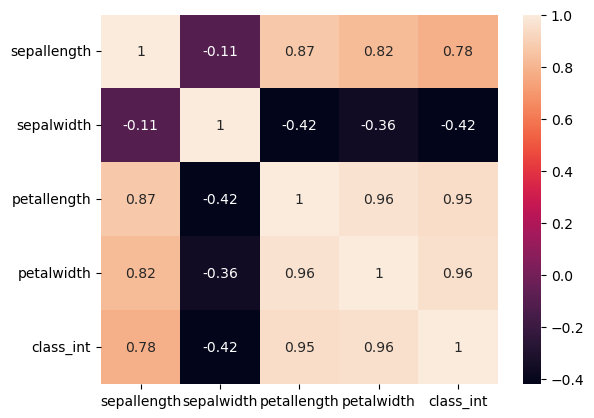

In [4]:
sns.heatmap(data.corr(), annot=True)
X = data.iloc[:, :4]
y = data["class_int"]
X

In [5]:
class RobustMinMaxScaler(BaseEstimator, TransformerMixin):
    # poprawic implementacje min_max
    def __init__(self, quantile_range=(25,75), clip_flag=False):
        self.quantile_range = quantile_range
        self.clip_flag = clip_flag

    def fit(self, X, y=None):

        qL, qR = self.quantile_range

        self.qL, self.qR = np.percentile(X, [qL, qR], axis=0)

        return self

    def transform(self, X):
        X_n = (X - self.qL) / (self.qR - self.qL)
        if self.clip_flag:
            X_n = np.clip(X_n, 0, 1)
        return X_n

In [6]:
class RobustScaler(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)

        self.median_ = np.median(X, axis=0)
        self.q1_ = np.percentile(X, 25, axis=0)
        self.q3_ = np.percentile(X, 75, axis=0)
        self.iqr_ = self.q3_ - self.q1_
        
        self.iqr_[self.iqr_ == 0] = 1e-9

        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        return (X - self.median_) / self.iqr_


In [20]:
class_weights = {
        0: 1.0,
        1: 2.0,  
        2: 3.0 
}

sample_weight = np.array([class_weights[yi] for yi in y])
len(sample_weight)

150

In [29]:
def create_pipeline(model, n_features, scaler):
    if model == "LogisticRegression":
        base_model = LogisticRegression(multi_class="multinomial", solver="lbfgs", max_iter=500)
        steps = [
             ("scaler", scaler),
             ("rfe", RFE(estimator=clone(base_model), n_features_to_select=n_features)),
             ("model", clone(base_model))]
    elif model == "KNeighborsClassifier":
        base_model = KNeighborsClassifier()
        steps = [
             ("scaler", scaler),
             ("model", clone(base_model))]
    pipeline = Pipeline(steps)

    return pipeline

In [32]:
import warnings

warnings.filterwarnings("ignore")

def objective(trial):
    
    
    n_features = trial.suggest_int("n_features", 1, X.shape[1])
    model_choice = trial.suggest_categorical("model", ["LogisticRegression", "KNeighborsClassifier"])
    scaler_choice = trial.suggest_categorical("scaler", ["StandardScaler", "RobustMinMaxScaler", "RobustScaler"])

    scalers = {
        "StandardScaler": StandardScaler(),
        "RobustMinMaxScaler": RobustMinMaxScaler(),
        "RobustScaler": RobustScaler()
    }
    scaler = scalers[scaler_choice]
    
    pipeline = create_pipeline(model_choice, n_features, scaler)

    last_step_name = pipeline.steps[-1][0]

    if model_choice == "LogisticRegression":
        fit_params = {f"{last_step_name}__sample_weight": sample_weight}
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        scores = []

        for train_idx, test_idx in cv.split(X, y):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
            sw_train = sample_weight[train_idx]
            
            pipeline.fit(X_train, y_train, **{f"{last_step_name}__sample_weight": sw_train})
            scores.append(pipeline.score(X_test, y_test))
    
    
        return np.mean(scores)
        
    else:
        fit_params = {} 
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        scores = cross_val_score(pipeline, X, y, cv=cv, scoring="accuracy")

        return scores.mean()

    

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)
    
    

[I 2025-12-09 12:18:38,364] A new study created in memory with name: no-name-fedce077-3892-4e8f-a945-95ab876228a1
[I 2025-12-09 12:18:38,521] Trial 0 finished with value: 0.9533333333333334 and parameters: {'n_features': 2, 'model': 'LogisticRegression', 'scaler': 'RobustMinMaxScaler'}. Best is trial 0 with value: 0.9533333333333334.
[I 2025-12-09 12:18:38,669] Trial 1 finished with value: 0.9533333333333334 and parameters: {'n_features': 2, 'model': 'LogisticRegression', 'scaler': 'StandardScaler'}. Best is trial 0 with value: 0.9533333333333334.
[I 2025-12-09 12:18:38,795] Trial 2 finished with value: 0.9400000000000001 and parameters: {'n_features': 3, 'model': 'LogisticRegression', 'scaler': 'StandardScaler'}. Best is trial 0 with value: 0.9533333333333334.
[I 2025-12-09 12:18:38,950] Trial 3 finished with value: 0.9533333333333334 and parameters: {'n_features': 2, 'model': 'LogisticRegression', 'scaler': 'RobustScaler'}. Best is trial 0 with value: 0.9533333333333334.
[I 2025-12-0

In [9]:
best_val_lr = 0
best_val_knn = 0

for trial in study.trials:
    if trial.params["model"] == "LogisticRegression":
        if trial.value > best_val_lr:
            best_val_lr = trial.value
            best_lr_params = trial.params
    elif trial.params["model"] == "KNeighborsClassifier":
        if trial.value > best_val_knn :
            best_val_knn = trial.value
            best_knn_params = trial.params

print("Best LR params:", best_lr_params, "Accuracy:", best_val_lr)
print("Best KNN params:", best_knn_params, "Accuracy:", best_val_knn)


Best LR params: {'n_features': 3, 'model': 'LogisticRegression', 'scaler': 'RobustScaler'} Accuracy: 0.9600000000000002
Best KNN params: {'n_features': 2, 'model': 'KNeighborsClassifier', 'scaler': 'StandardScaler'} Accuracy: 0.9733333333333334


In [10]:
best_lr_model = create_pipeline("LogisticRegression", best_lr_params["n_features"])
best_knn_model = create_pipeline("KNeighborsClassifier", best_knn_params["n_features"])

best_lr_model.fit(X, y)
best_knn_model.fit(X, y)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_lr = cross_val_score(best_lr_model, X, y, cv=cv, scoring="accuracy")
scores_knn = cross_val_score(best_knn_model, X, y, cv=cv, scoring="accuracy")

stat, p = wilcoxon(scores_lr, scores_knn)
print("Wilcoxon stat:", stat)
print("p-value:", p)

TypeError: create_pipeline() missing 1 required positional argument: 'scaler'

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_lr = best_lr_model.predict(X)
cm_lr = confusion_matrix(y, y_pred_lr)
disp = ConfusionMatrixDisplay(cm_lr, display_labels=iris.target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()